<a href="https://colab.research.google.com/github/AhmadEgbaria1/deep-learning-project1/blob/main/final22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning: Assignment #1
## Submission date: 03/12/2025, 23:59.
### Topics:
- Logistic Regression
- Feedforward Neural Networks
- Backpropagation
- Optimization
- Batch Normalization

**Submitted by:**

- Ahmad Egbaria
- Morad kutt


**Assignment Instruction:**

· Submissions are in **pairs only**. Write both names + IDs at the top of the notebook.

· Keep your code **clean, concise, and readable**.

· You may work in your IDE, but you **must** paste the final code back into the **matching notebook cells** and run it there.  


· <font color='red'>Write your textual answers in red.</font>  
(e.g., `<span style="color:red">your answer here</span>`)

· All figures, printed results, and outputs should remain visible in the notebook.  
Run **all cells** before submitting and **do not clear outputs**.

· Use relative paths — **no absolute file paths** pointing to local machines.

· **Important:** Your submission must be entirely your own.  
Any form of plagiarism (including uncredited use of ChatGPT or AI tools) will result in **grade 0** and disciplinary action.


In [ ]:
# --- Global Setup ---

# Import Libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import itertools
import random
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.optim as optim
import torch.nn.init as init

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## Question 1 — From Classic ML to Deep Networks

In this question we embark on a short expedition from classic Machine Learning to Deep Learning.

We will compare the performance of a **multiclass logistic regression** to a **multi-layer perceptron (MLP)** on the **MNIST** dataset.


Start by running this cell which includes relative setup and useful helper functions implemented for you to use.

In [ ]:
# --- Define Seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Helper Functions To Use ---
def accuracy(logits: torch.Tensor, y: torch.Tensor):
    """Top-1 accuracy for logits [N,C] and labels [N]."""
    return (logits.argmax(dim=1) == y).float().mean().item()

def count_params(obj):
    """
    Count trainable parameters.
    - If obj is (W, b) tuple → counts elements.
    - If obj is a nn.Module → sums requires_grad params.
    """
    if isinstance(obj, tuple) and len(obj) == 2:
        W, b = obj
        return W.numel() + b.numel()
    if isinstance(obj, nn.Module):
        return sum(p.numel() for p in obj.parameters() if p.requires_grad)
    raise TypeError("count_params expects (W,b) or nn.Module.")


@torch.no_grad()
def evaluate_acc(W: torch.Tensor, b: torch.Tensor, loader):
    """Dataset-level accuracy for a linear softmax model parameterized by (W,b)."""
    total_acc, total_n = 0.0, 0
    for xb, yb in loader:
        xb = xb.to(DEVICE).view(xb.size(0), -1)
        yb = yb.to(DEVICE)
        logits = xb @ W + b
        batch_acc = accuracy(logits, yb)
        n = xb.size(0)
        total_acc += batch_acc * n         # weight by batch size
        total_n   += n
    return total_acc / total_n


# Use this function in the training loop for your nn.Module
@torch.no_grad()
def evaluate_module(model: nn.Module, loader):
    model.eval()
    total_acc, total_n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        batch_acc = accuracy(logits, yb)
        n = xb.size(0)
        total_acc += batch_acc * n
        total_n   += n
    return total_acc / total_n

### Load & Preprocess the Data:



We first load the MNIST dataset as provided by `torchvision`. All images are automatically converted to tensors in the range $[0,1]$.


In [ ]:
# Load the raw MNIST dataset
transform = transforms.ToTensor()

train_full = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(f"\n Train set: {len(train_full)} samples  |  Test set: {len(test_set)} samples")


 Train set: 60000 samples  |  Test set: 10000 samples


Implement the following steps:

1. **Split the data:**
   - The MNIST test set is already provided.
   - From the full training set, create an 80/20 split into **train** and **validation** subsets.

2. **Construct `DataLoader` objects:**
   - `train_loader` → use shuffling.
   - `val_loader` → no shuffling.
   - `test_loader` → no shuffling.2.

3. **Print a quick sanity check:**
   - batch shapes `(batch_size = 128, 1, 28, 28)`
   - label range (0–9)

*Example format:*
```python
Batch: torch.Size([128, 1, 28, 28]) torch.Size([128]) | pixel range = (0.0, 1.0)


In [ ]:
from torch.utils.data import random_split

# Total size of the training set
train_size = int(0.8 * len(train_full))   # 80%
val_size   = len(train_full) - train_size # 20%

# Split the full training dataset
train_set, val_set = random_split(train_full, [train_size, val_size])

print(f"Train set: {len(train_set)} samples | Validation set: {len(val_set)} samples")



from torch.utils.data import DataLoader

batch_size = 128

#create data loaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print("DataLoaders created successfully!")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")



# pick a batch from the train loader
images, labels = next(iter(train_loader))

print(f"Batch: {images.shape} {labels.shape} | pixel range = ({images.min().item():.1f}, {images.max().item():.1f})")

#check label range
print(f"Label range: {labels.min().item()}–{labels.max().item()}")




Train set: 48000 samples | Validation set: 12000 samples
DataLoaders created successfully!
Train batches: 375 | Val batches: 94 | Test batches: 79
Batch: torch.Size([128, 1, 28, 28]) torch.Size([128]) | pixel range = (0.0, 1.0)
Label range: 0–9


###  Multiclass Logistic Regression



In binary logistic regression, we model  
$$
P(y=1 \mid x) = \sigma(w^\top x + b)
$$
where  $\sigma$ is the sigmoid activation function.

For **multiclass** problems, like ours where MNIST is a dataset of images of 10 digits, hence 10 classes, we generalize this idea.

Each class $c \in \{0, \dots, 9\}$ has its own weight vector  $w_c$ and bias  $b_c$.

We stack them into a **weight matrix**  $W \in \mathbb{R}^{d \times C}$
and a **bias vector**  $b \in \mathbb{R}^{C}$.

<br>

Generally speaking, we compute a forward pass by computing:

$$
z_i = W^\top x_i + b
$$

where $W \in \mathbb{R}^{d \times C}$ is the weight matrix and $b \in \mathbb{R}^C$ is the bias vector.

<br>

We then obtain class probabilities via the softmax function:

$$
p_i(c) = \frac{e^{z_i(c)}}{\sum_{k=1}^{C} e^{z_i(k)}}
$$

The model is trained by minimizing the **cross-entropy loss** between the predicted probabilities and the true class labels:

$$
\mathcal{L}(W,b) = -\frac{1}{N} \sum_{i=1}^N \log p_i(y_i)
$$

and the parameters are updated using **gradient descent**:

$$
W \leftarrow W - \eta \, \nabla_W \mathcal{L}, \qquad
b \leftarrow b - \eta \, \nabla_b \mathcal{L}
$$


<br><br>
In this question, you will build a multiclass logistic regression model from scratch, train it using the cross-entropy loss, and optimize it with gradient descent.

<br>

You will then evaluate the model’s performance on the MNIST dataset, and train it on 20 epochs.


In [ ]:
import math

def logistic_regression(train_loader, val_loader, epochs=20, lr=0.1, tol=1e-6):
    """
    Train a multiclass logistic regression model with gradient descent.
    Uses only basic torch ops (no autograd). Returns (W, b).
    """
    # infer dims
    x0, _ = next(iter(train_loader))
    B, Cx, H, Wimg = x0.shape
    d = Cx * H * Wimg
    C = 10

    # params
    W = torch.zeros(d, C)      # [d, C]
    b = torch.zeros(C)         # [C]
    W = W.to(DEVICE)
    b = b.to(DEVICE)


    def softmax(z):
        z = z - z.max(dim=1, keepdim=True).values
        ez = torch.exp(z)
        return ez / ez.sum(dim=1, keepdim=True)

    def ce_loss(probs, y_onehot, eps=1e-12):
        return -(y_onehot * torch.log(probs.clamp_min(eps))).sum(dim=1).mean()



    for epoch in range(1, epochs + 1):
        running_loss = 0.0
        steps = 0
        for X, y in train_loader:
            X = X.to(DEVICE).view(X.size(0), -1)
            y = y.to(DEVICE)          # [B, d]
            y_onehot = torch.nn.functional.one_hot(y, num_classes=C).float()

            # forward
            logits = X @ W + b                 # [B, C]
            probs  = softmax(logits)           # [B, C]
            loss   = ce_loss(probs, y_onehot)  # scalar

            # gradients (mean over batch)
            dZ = (probs - y_onehot) / X.size(0)   # [B, C]
            gW = X.t() @ dZ                        # [d, C]
            gb = dZ.sum(dim=0)                     # [C]

            # update
            W -= lr * gW
            b -= lr * gb

            running_loss += loss.item()
            steps += 1

        val_acc = evaluate_acc(W, b, val_loader)
        avg_loss = running_loss / max(1, steps)

        # simple convergence check on gradient norm from last step
        grad_norm = torch.linalg.norm(gW) + torch.linalg.norm(gb)
        print(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | val_acc {val_acc*100:.2f}% | grad_norm {grad_norm:.3e}")
        if grad_norm.item() < tol:
            print("Early stop: gradient norm below tolerance.")
            break

    return W, b



Now run the next cell to evaluate your multiclass logistic regression.

We use the `evaluate_acc` helper function to evaluate.


In [ ]:
# TODO: Run
W, b = logistic_regression(train_loader, val_loader, epochs=20, lr=0.1)

model = (W, b)

# Evaluate
val_acc = evaluate_acc(W, b, val_loader)
test_acc = evaluate_acc(W, b, test_loader)

print(f"\nNumber of Parameters: {count_params(model):,}")
print(f"Val. acc.: {val_acc:.4f}")
print(f"Test acc.: {test_acc:.4f}")

Epoch 01 | loss 0.6104 | val_acc 88.74% | grad_norm 3.687e-01
Epoch 02 | loss 0.3866 | val_acc 89.58% | grad_norm 3.507e-01
Epoch 03 | loss 0.3508 | val_acc 90.02% | grad_norm 4.705e-01
Epoch 04 | loss 0.3324 | val_acc 90.42% | grad_norm 3.450e-01
Epoch 05 | loss 0.3207 | val_acc 90.63% | grad_norm 4.133e-01
Epoch 06 | loss 0.3118 | val_acc 90.82% | grad_norm 2.526e-01
Epoch 07 | loss 0.3053 | val_acc 90.83% | grad_norm 3.392e-01
Epoch 08 | loss 0.3001 | val_acc 90.92% | grad_norm 3.582e-01
Epoch 09 | loss 0.2956 | val_acc 91.01% | grad_norm 4.738e-01
Epoch 10 | loss 0.2919 | val_acc 91.17% | grad_norm 4.553e-01
Epoch 11 | loss 0.2888 | val_acc 91.20% | grad_norm 2.122e-01
Epoch 12 | loss 0.2860 | val_acc 91.27% | grad_norm 3.384e-01
Epoch 13 | loss 0.2833 | val_acc 91.33% | grad_norm 3.492e-01
Epoch 14 | loss 0.2813 | val_acc 91.28% | grad_norm 3.747e-01
Epoch 15 | loss 0.2793 | val_acc 91.23% | grad_norm 3.113e-01
Epoch 16 | loss 0.2775 | val_acc 91.46% | grad_norm 2.458e-01
Epoch 17

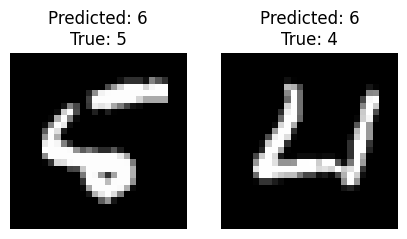

In [ ]:
import matplotlib.pyplot as plt

misclassified = []

# Go over the test set
for X, y in test_loader:
    X = X.to(DEVICE)
    y = y.to(DEVICE)

    X_flat = X.view(X.size(0), -1)
    logits = X_flat @ W + b
    preds = logits.argmax(dim=1)

    # save mistakes
    for i in range(len(preds)):
        if preds[i] != y[i]:
            misclassified.append((X[i].cpu(), preds[i].item(), y[i].item()))

    if len(misclassified) >= 2:
        break  # we only need 2 examples

# Plot the first two misclassified samples
fig, axes = plt.subplots(1, 2, figsize=(5, 3))

for ax, (img, pred, true) in zip(axes, misclassified[:2]):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Predicted: {pred}\nTrue: {true}")
    ax.axis("off")

plt.show()


Answer the following questions:

1. Is a *logistic regression* a sufficient model for this task?  
   What **constraints** does this model impose on the decision boundaries and on what it can “represent”?  
   What **modification** might help address these constraints?


2. Give two examples of incorrectly classified digits. Include the image of the misclassified digit,
the predicted class and the actual class in your write up

</br>

<font color='red'>1. No we dont think that logistic regression is sufficient model for this task we saw that the accuarcy is 91% that is not sufficient and we must get avery high accuarcy on such problem and that because logistic regression cant reognize diffrences that are not seprable by astraight hyperplane but MNIST digits are not linearly seprable

2.as we can see on the output from above the first example is an image of digit 5 but our model predicted it as 6 The digit 5 in this case has a closed loop at the bottom, making it visually similar to a sloppy 6. a linear model cannot capture the subtle nonlinear shape difference. example 2: is also on the image from above the true digit is 4 but the model predicted it as 6. The digit 4 here has a curved shape instead of sharp angles. Logistic regression cannot distinguish curved vs angular shapes due to its linear decision boundaries.</font>

### Feedforward Neural Network




As we learned in class, a **Feedforward Neural Network (FFNN)** maps an input — in our case, a flattened $28 \times 28$ image, $x \in \mathbb{R}^{784}$ — through a sequence of **linear layers** interleaved with **nonlinear activation functions**.

Formally, the computation proceeds as follows:

$$
y^{(1)} = \sigma (W^{(1)}x+b^{(1)})
$$
$$
y^{(\ell)} = \sigma (W^{(1)}y^{(\ell -1)}+b^{(1)})
$$


Where:
- $y^{(i)}$ is the output of layer $i$.
- $W^{(i)}$ and $b^{(i)}$ are the weight matrix and bias vector for layer $i$, respectively.
- $\sigma ^{(i)}$ is the activation function used in layer $i$.

In this section you will implement a FFNN from scratch, and see how it fairs with the MNIST dataset.

In the cell below, implement your `MLP` network, a two-layer Multi-Layer Perceptron with no regularization to classify MNIST with the following architecture:

- Input layer : 784 nodes (MNIST images size)
- First hidden layer : 400 nodes
- Second hidden layer : 400 nodes
- Output layer : 10 nodes (number of classes for MNIST)


<br>

- Use `RELU()` as your activation function for each layer.

In [ ]:
class MLP(nn.Module):
    def __init__(self):
          super().__init__()
          self.model = nn.Sequential(
            nn.Flatten(),                 # [B, 1, 28, 28] -> [B, 784]
            nn.Linear(28*28, 400),        # 784 -> 400
            nn.ReLU(),                    # activation
            nn.Linear(400, 400),          # 400 -> 400
            nn.ReLU(),                    # activation
            nn.Linear(400, 10)            # 400 -> 10
        )
    def forward(self, x):
        return self.model(x)

After defining `MLP` class, train it for **20 epochs** using **cross-entropy loss** and **Adam** as your optimizer.  

At the end of every epoch, evaluate the model both on the training set and on the validation set. You should print the loss, the training accuracy, and the validation accuracy so that you can monitor how the model improves over time and detect potential overfitting.

Once training is complete, produce a plot that shows how the training accuracy and the validation accuracy evolve across the 20 epochs. The plot should clearly reflect the learning dynamics of your model and allow you to compare its performance to the logistic regression model from the previous section.

> You already have the helpers `evaluate_module`, `accuracy`, and `count_params` in the setup cell— you may use them directly in your implementation.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

#create the model
mlp = MLP().to(DEVICE)
print("Num params (MLP):", count_params(mlp))

#cost function and adam
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)

num_epochs = 20

train_acc_hist = []
val_acc_hist   = []
train_loss_hist = []

for epoch in range(1, num_epochs + 1):
    mlp.train()
    running_loss = 0.0
    steps = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        # forward
        logits = mlp(xb)
        loss = criterion(logits, yb)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        steps += 1

    avg_loss = running_loss / max(1, steps)

    # train + val accuarcy
    train_acc = evaluate_module(mlp, train_loader)
    val_acc   = evaluate_module(mlp, val_loader)

    train_loss_hist.append(avg_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    print(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | "
          f"train_acc {train_acc*100:.2f}% | val_acc {val_acc*100:.2f}%")


Num params (MLP): 478410
Epoch 01 | loss 0.3139 | train_acc 96.48% | val_acc 95.42%
Epoch 02 | loss 0.1107 | train_acc 97.40% | val_acc 96.33%
Epoch 03 | loss 0.0715 | train_acc 98.31% | val_acc 97.03%
Epoch 04 | loss 0.0511 | train_acc 98.47% | val_acc 97.20%
Epoch 05 | loss 0.0379 | train_acc 99.37% | val_acc 97.42%
Epoch 06 | loss 0.0267 | train_acc 99.26% | val_acc 97.37%
Epoch 07 | loss 0.0216 | train_acc 98.94% | val_acc 97.19%
Epoch 08 | loss 0.0184 | train_acc 99.65% | val_acc 97.65%
Epoch 09 | loss 0.0175 | train_acc 99.72% | val_acc 97.63%
Epoch 10 | loss 0.0138 | train_acc 99.58% | val_acc 97.60%
Epoch 11 | loss 0.0124 | train_acc 99.49% | val_acc 97.58%
Epoch 12 | loss 0.0135 | train_acc 99.25% | val_acc 97.31%
Epoch 13 | loss 0.0063 | train_acc 99.78% | val_acc 97.72%
Epoch 14 | loss 0.0139 | train_acc 99.71% | val_acc 97.63%
Epoch 15 | loss 0.0092 | train_acc 99.27% | val_acc 97.24%
Epoch 16 | loss 0.0111 | train_acc 99.75% | val_acc 97.82%
Epoch 17 | loss 0.0075 | train_

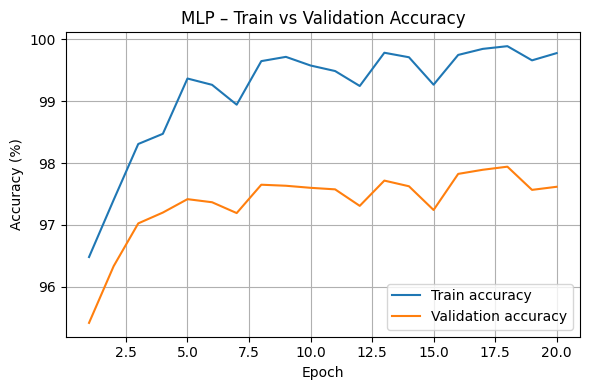

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)  # num_epochs = 20

plt.figure(figsize=(6, 4))


train_acc_percent = [a * 100 for a in train_acc_hist]
val_acc_percent   = [a * 100 for a in val_acc_hist]

plt.plot(epochs, train_acc_percent, label="Train accuracy")
plt.plot(epochs, val_acc_percent,   label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("MLP – Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<font color="red">Answer the following questions:</font>

<ol>
  <li>
    Using your results, explain why this model outperforms the logistic-regression baseline.
    What key property of the architecture could be tied to the success?
    Cite specific evidence from your plots or errors.
    <br>
    <font color="red">as we saw above, the MLP clearly outperforms the logistic-regression baseline on MNIST. the logistic regression reached around 92%  validation accuarcy, but NLP reaches about 98% validation accuarcy after 20 epoches the key of this succes is because logisitc regression cannot recognize non linear patterns, but after we made the MLP and adding the hidden layers with Relu activation that make the mode more "stronger" and can recognize non linear patterns, so this diffrence make the accuarcy from 92% to 98% and thats very good improvment.</font>
  </li>
<br>
  <li>
    Did you need all 20 epochs? If not, choose a stopping point from the validation curve, and justify it.
    Propose a concrete rule you would use next time to limit computation waste (spell out the metric and the trigger).
    <br>
    <font color="red">no
    we dont need all of the 20 epochs to stop
    we can stop our process on epoch 9 or 10 because we are from epoch 9 our improvment to the accuarcy started to be very slow and ince it up ince down so we can stay in this situation 2 or 3 epoches and then to stop because in this situation we are in overfitting and we running this process with no advantage </font>
  </li>
    

</ol>


### Exploring Initialization

Now, we’ll explore how **weight initialization** affects training dynamics and accuracy. In this section, you will expirement with different initilization methods, **changing only the initialization scheme** while keeping **everything else fixed**, including the model architecture, optimizer, data splits, number of epochs, batch size, etc.

<br>

In the previous code, you used PyTorch’s default: **Kaiming/He initialization**, which scales weights so that
$$
\mathrm{Var}(W_{ij}) \approx \frac{2}{\text{fan}_{in}}
$$
to help stabilize activations and gradients with ReLU layers.

In this section, you'll compare this baseline to four alternatives:
1. Zero initialization
2. Uniform $[0,1]$
3. Standard Normal: $\mathcal{N}(0,1)$
4. Xavier initialization

For each scheme, reinitialize <strong>all</strong> linear layers (weights and biases), train for 20 epochs using adam optimizer, and record validation accuracy per epoch and the final test accuracy. Then plot all validation-accuracy curves on one figure, report the final test accuracies for each method.

> Tip: Recreate a **fresh model** for each initialization; don’t re-use trained weights between runs.

In [ ]:
import torch.nn.init as init

def init_weights(model, mode: str):
    """
    Initialize all Linear layer weights in the MLP according to the selected mode.
    modes: zero,uniform, normal, xavier
    this function iterates through all layers of the model and applies the
    chosen initialization to Linear layers only.
    """
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if mode == "zero":
                m.weight.data.zero_()
                m.bias.data.zero_()
            elif mode == "uniform":
                init.uniform_(m.weight, 0.0, 1.0)
                m.bias.data.zero_()
            elif mode == "normal":
                init.normal_(m.weight, mean=0.0, std=1.0)
                m.bias.data.zero_()
            elif mode == "xavier":
                init.xavier_uniform_(m.weight)
                m.bias.data.zero_()
            else:
                raise ValueError(f"Unknown init mode: {mode}")





def train_mlp_with_init(init_mode: str, num_epochs: int = 20, lr: float = 1e-3):
    print(f"\n=== Init mode: {init_mode} ===")
    model = MLP().to(DEVICE)

    # zero weights
    init_weights(model, init_mode)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    val_hist = []
    train_hist = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        steps = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            steps += 1

        avg_loss   = running_loss / max(1, steps)
        train_acc  = evaluate_module(model, train_loader)
        val_acc    = evaluate_module(model, val_loader)

        train_hist.append(train_acc)
        val_hist.append(val_acc)

        print(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | "
              f"train_acc {train_acc*100:.2f}% | val_acc {val_acc*100:.2f}%")

    # test accuracy
    test_acc = evaluate_module(model, test_loader)
    print(f"Final test_acc ({init_mode}): {test_acc*100:.2f}%")

    return model, train_hist, val_hist, test_acc

init_modes = ["zero", "uniform", "normal", "xavier"]

results = {}

for mode in init_modes:
    model_mode, train_hist, val_hist, test_acc = train_mlp_with_init(mode)
    results[mode] = {
        "train_hist": train_hist,
        "val_hist": val_hist,
        "test_acc": test_acc,
    }



=== Init mode: zero ===
Epoch 01 | loss 2.3019 | train_acc 11.21% | val_acc 11.33%
Epoch 02 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 03 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 04 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 05 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 06 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 07 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 08 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 09 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 10 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 11 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 12 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 13 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 14 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 15 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 16 | loss 2.3014 | train_acc 11.21% | val_acc 11.33%
Epoch 17 | loss 2.3014 | train_

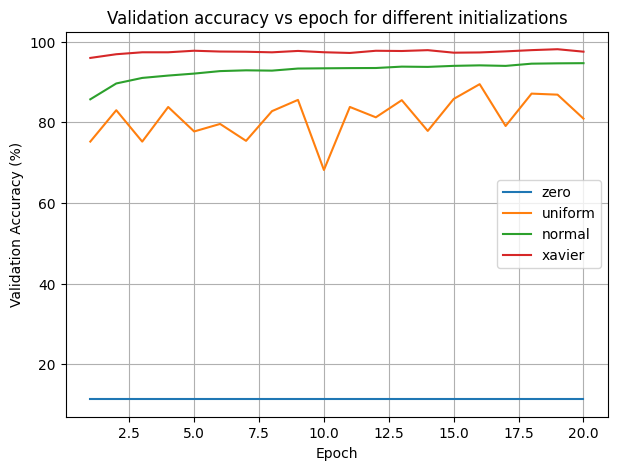

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, 21)

plt.figure(figsize=(7,5))
# If you also saved the validation history of the default MLP (He initialization),
# you can plot it here:
# plt.plot(epochs, [a*100 for a in val_acc_hist], label="He (default)")

for mode in ["zero", "uniform", "normal", "xavier"]:
    vals = results[mode]["val_hist"]
    plt.plot(epochs, [a*100 for a in vals], label=mode)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation accuracy vs epoch for different initializations")
plt.legend()
plt.grid(True)
plt.show()


<font color="red">Answer the following question:</font>

Why does zero initialization cause training to fail, even though the optimizer still updates the weights?
<font color="red">zero initalization make all the of the neurons identecal, so they produce the same outputs and receive the same gradients, causing them to stay identical forever. using diffrent activations could break symmetry but thats not how neural networks working, instead prober initaliztion like xavier break the symmetry in acotrolled and stabled way</font>


### Exploring Optimization Methods


Finally, we’ll explore how **different Optimization** methods affect training dynamics and accuracy. In this section, you will expirement with different optimizers, **changing only the optimization method** while keeping **everything else fixed**, including the model architecture, selecting the best initialization scheme you got earlier, data splits, number of epochs, batch size, etc.

<br>

Up to this point, you used the **Adam** optimizer. Here, you will experiment with alternative optimizers and compare their performance under the same settings.

In this section, you'll compare this baseline to three other alternatives:
1. Stochastic Gradient Descent (SGD)
2. RMSProp
3. Adagrad


As you did with initilization exploring, for each optimizer, create a **fresh model** and apply the **same fixed initialization** to all `nn.Linear` layers (weights & biases). Train the model for **20 epochs**. Plot all **validation-accuracy vs. epoch** curves on one figure and compare test accuracies.

> Tip: Recreate a **fresh model** for each initialization; don’t re-use trained weights between runs.

In [ ]:
def make_optimizer(model, opt_name: str, lr: float = 1e-3):
    if opt_name == "adam":
        return optim.Adam(model.parameters(), lr=1e-3)
    elif opt_name == "sgd":
        return optim.SGD(model.parameters(), lr=0.1)
    elif opt_name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=1e-3)
    elif opt_name == "adagrad":
        return optim.Adagrad(model.parameters(), lr=1e-2)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")


def train_mlp_with_optimizer(opt_name: str,
                             init_mode: str = "xavier",
                             num_epochs: int = 20,
                             lr: float = 1e-3):
    print(f"\n=== Optimizer: {opt_name} | Init: {init_mode} ===")

    model = MLP().to(DEVICE)
    init_weights(model, init_mode)   # same init for all the optimizes

    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, opt_name, lr=lr)

    train_hist = []
    val_hist   = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        steps = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            steps += 1

        avg_loss  = running_loss / max(1, steps)
        train_acc = evaluate_module(model, train_loader)
        val_acc   = evaluate_module(model, val_loader)

        train_hist.append(train_acc)
        val_hist.append(val_acc)

        print(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | "
              f"train_acc {train_acc*100:.2f}% | val_acc {val_acc*100:.2f}%")

    test_acc = evaluate_module(model, test_loader)
    print(f"Final test_acc ({opt_name}): {test_acc*100:.2f}%")

    return model, train_hist, val_hist, test_acc


In [ ]:
optimizers = ["adam", "sgd", "rmsprop", "adagrad"]
opt_results = {}

for opt in optimizers:
    model_opt, train_hist, val_hist, test_acc = train_mlp_with_optimizer(opt_name=opt,
                                                                         init_mode="xavier",
                                                                         num_epochs=20,
                                                                         lr=1e-3)
    opt_results[opt] = {
        "train_hist": train_hist,
        "val_hist": val_hist,
        "test_acc": test_acc,
    }



=== Optimizer: adam | Init: xavier ===
Epoch 01 | loss 0.2570 | train_acc 97.06% | val_acc 95.98%
Epoch 02 | loss 0.0928 | train_acc 98.40% | val_acc 97.14%
Epoch 03 | loss 0.0582 | train_acc 99.08% | val_acc 97.55%
Epoch 04 | loss 0.0391 | train_acc 99.26% | val_acc 97.44%
Epoch 05 | loss 0.0298 | train_acc 99.41% | val_acc 97.51%
Epoch 06 | loss 0.0213 | train_acc 99.57% | val_acc 97.62%
Epoch 07 | loss 0.0207 | train_acc 99.50% | val_acc 97.63%
Epoch 08 | loss 0.0141 | train_acc 99.46% | val_acc 97.52%
Epoch 09 | loss 0.0150 | train_acc 99.60% | val_acc 97.47%
Epoch 10 | loss 0.0111 | train_acc 99.72% | val_acc 97.82%
Epoch 11 | loss 0.0130 | train_acc 99.82% | val_acc 97.92%
Epoch 12 | loss 0.0086 | train_acc 99.77% | val_acc 97.67%
Epoch 13 | loss 0.0091 | train_acc 99.68% | val_acc 97.69%
Epoch 14 | loss 0.0137 | train_acc 99.65% | val_acc 97.51%
Epoch 15 | loss 0.0098 | train_acc 99.84% | val_acc 98.02%
Epoch 16 | loss 0.0043 | train_acc 99.80% | val_acc 97.80%
Epoch 17 | loss 

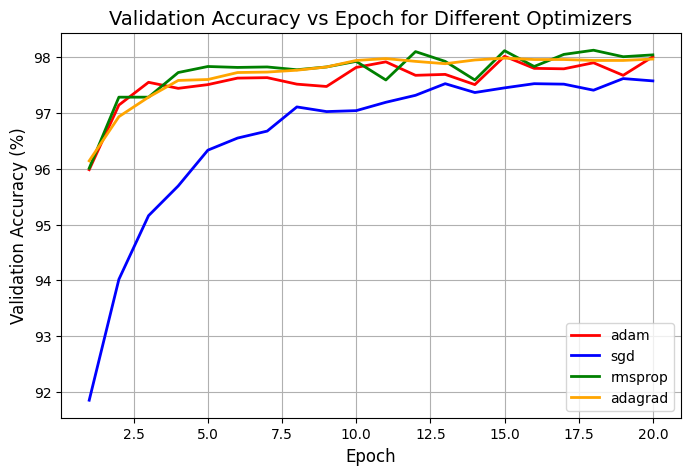

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, 21)

plt.figure(figsize=(8, 5))

colors = {
    "adam": "red",
    "sgd": "blue",
    "rmsprop": "green",
    "adagrad": "orange"
}

for opt_name in ["adam", "sgd", "rmsprop", "adagrad"]:
    vals = opt_results[opt_name]["val_hist"]
    plt.plot(epochs, [v * 100 for v in vals],
             label=opt_name,
             linewidth=2,
             color=colors[opt_name])

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation Accuracy (%)", fontsize=12)
plt.title("Validation Accuracy vs Epoch for Different Optimizers", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


#### Reflection

Consider the interaction between initialization and optimization:

- Combine the **best-performing initialization** with the **worst-performing optimizer**.
- Combine the **worst-performing initialization** with the **best-performing optimizer**.

Run both experiments and compare the learning dynamics.



In [ ]:

def train_mlp_combo(init_mode, opt_name, num_epochs=20, lr=1e-3):
    print(f"\n=== Init: {init_mode} | Optimizer: {opt_name} ===")
    model = MLP().to(DEVICE)
    init_weights(model, init_mode)

    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, opt_name, lr=lr)

    val_hist = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, steps = 0.0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            steps += 1

        avg_loss = running_loss / max(1, steps)
        val_acc = evaluate_module(model, val_loader)
        val_hist.append(val_acc)

        print(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | val_acc {val_acc*100:.2f}%")

    test_acc = evaluate_module(model, test_loader)
    print(f"Final test_acc: {test_acc*100:.2f}%")

    return val_hist, test_acc


# 1) best init + worst optimizer  → xavier + sgd
val_xavier_sgd, test_xavier_sgd = train_mlp_combo("xavier", "sgd")

# 2) worst init + best optimizer → zero + adam
val_zero_adam, test_zero_adam   = train_mlp_combo("zero", "adam")



=== Init: xavier | Optimizer: sgd ===
Epoch 01 | loss 0.4439 | val_acc 92.48%
Epoch 02 | loss 0.2094 | val_acc 93.94%
Epoch 03 | loss 0.1560 | val_acc 95.39%
Epoch 04 | loss 0.1244 | val_acc 95.79%
Epoch 05 | loss 0.1019 | val_acc 96.30%
Epoch 06 | loss 0.0864 | val_acc 96.62%
Epoch 07 | loss 0.0745 | val_acc 96.86%
Epoch 08 | loss 0.0644 | val_acc 96.74%
Epoch 09 | loss 0.0560 | val_acc 97.11%
Epoch 10 | loss 0.0491 | val_acc 97.15%
Epoch 11 | loss 0.0426 | val_acc 97.11%
Epoch 12 | loss 0.0381 | val_acc 97.38%
Epoch 13 | loss 0.0332 | val_acc 97.33%
Epoch 14 | loss 0.0296 | val_acc 97.25%
Epoch 15 | loss 0.0265 | val_acc 97.38%
Epoch 16 | loss 0.0233 | val_acc 97.45%
Epoch 17 | loss 0.0205 | val_acc 97.28%
Epoch 18 | loss 0.0180 | val_acc 97.11%
Epoch 19 | loss 0.0161 | val_acc 97.47%
Epoch 20 | loss 0.0145 | val_acc 97.54%
Final test_acc: 97.85%

=== Init: zero | Optimizer: adam ===
Epoch 01 | loss 2.3018 | val_acc 11.33%
Epoch 02 | loss 2.3014 | val_acc 11.33%
Epoch 03 | loss 2.30

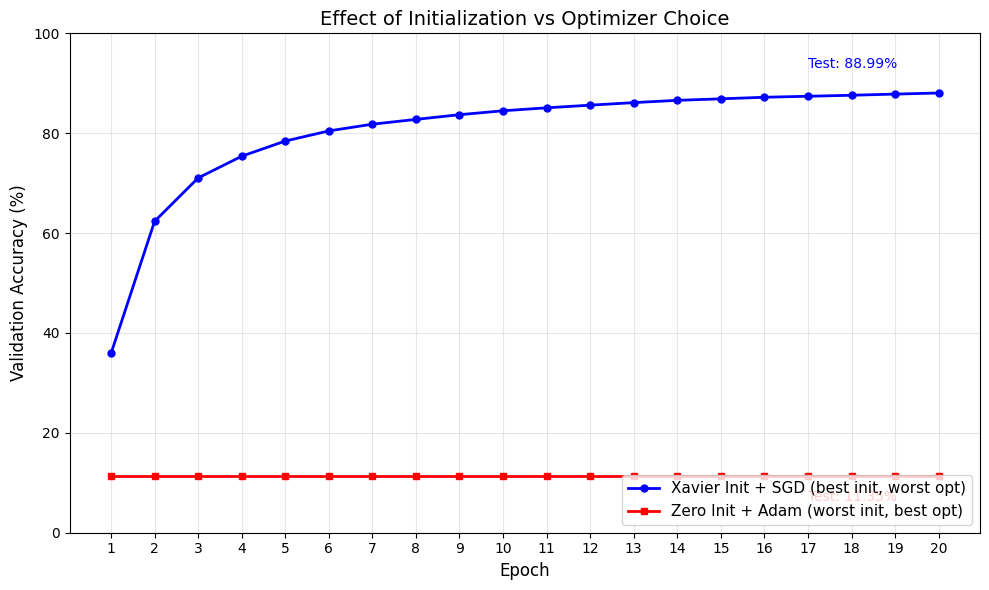


SUMMARY
Xavier + SGD  → Final Test Accuracy: 88.99%
Zero + Adam   → Final Test Accuracy: 11.35%


In [ ]:
# Plotting the comparison
plt.figure(figsize=(10, 6))

epochs = range(1, len(val_xavier_sgd) + 1)

plt.plot(epochs, [v * 100 for v in val_xavier_sgd], 'b-o', label='Xavier Init + SGD (best init, worst opt)', linewidth=2, markersize=5)
plt.plot(epochs, [v * 100 for v in val_zero_adam], 'r-s', label='Zero Init + Adam (worst init, best opt)', linewidth=2, markersize=5)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.title('Effect of Initialization vs Optimizer Choice', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(epochs)
plt.ylim([0, 100])

# Add final test accuracy annotations
plt.annotate(f'Test: {test_xavier_sgd*100:.2f}%', xy=(len(epochs), val_xavier_sgd[-1]*100),
             xytext=(len(epochs)-3, val_xavier_sgd[-1]*100 + 5), fontsize=10, color='blue')
plt.annotate(f'Test: {test_zero_adam*100:.2f}%', xy=(len(epochs), val_zero_adam[-1]*100),
             xytext=(len(epochs)-3, val_zero_adam[-1]*100 - 5), fontsize=10, color='red')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Xavier + SGD  → Final Test Accuracy: {test_xavier_sgd*100:.2f}%")
print(f"Zero + Adam   → Final Test Accuracy: {test_zero_adam*100:.2f}%")
print("="*50)

## Question 2:  Multidimentional XOR and backpropagation

Given $ d $ bits $b=(b_1, b_2, ... , b_d) \in \{0, 1\}^d$, we define $$XOR(b) = Σ_{i=1}^db_i\ mod\ 2$$

In this question, you will train a feedforward neural network to model the multidimensional XOR problem.




The following function returns the labeled XOR "dataset" for any given $d$ (`dim`)

In [ ]:
def XORData(dim):
  X = np.array(list(itertools.product([0, 1], repeat=dim)))
  Y = X.sum(axis=1)%2
  return X, Y

Implement the following:

1. A linear layer class:`Linear(torch.nn.Module)`\
• You should inherit from `torch.nn.Module`\
• You can not use `torch.nn.LinearLayer` or any other model implemented by PyTorch, only tensors. Wrap every tensor object with `torch.nn.Parameter` (for the optimizer).\
• Use `torch.randn` to initialize the parameter tensors (weights matrix and biases vector)\
• Implement the `forward` method according to the linear model $y = Wx + b$\
• The number of parameters should be defined by `in_features` and `out_features` \
• Make sure to enable gradient computation!

In [ ]:
class Linear(nn.Module):
    def __init__(self, in_features, out_features):
        super(Linear, self).__init__()
        # Initialize weights and biases using torch.randn
        # Wrap with nn.Parameter for gradient tracking and optimizer compatibility
        self.W = nn.Parameter(torch.randn(in_features, out_features, requires_grad=True))
        self.b = nn.Parameter(torch.randn(out_features, requires_grad=True))

    def forward(self, x):
        # Linear transformation: y = xW + b
        return x @ self.W + self.b

2. A feedforward neural network:`FFNet(torch.nn.module)`\
• Use the `Linear` class you implemented to construct a network with `in_features` input size, `out_features` output size, and one hidden layer with `hidden_size` neurons.\
• Use the sigmoid activation function on top of the hidden layer neurons.

In [ ]:
class FFNet(nn.Module):
    def __init__(self, in_features, out_features, hidden_size):
        super(FFNet, self).__init__()
        # First linear layer: input to hidden
        self.layer1 = Linear(in_features, hidden_size)
        # Second linear layer: hidden to output
        self.layer2 = Linear(hidden_size, out_features)
        # Sigmoid activation function
        self.sigmoid = torch.sigmoid

    def forward(self, x):
        # Forward pass through the network
        h = self.layer1(x)          # Linear transformation
        h = self.sigmoid(h)          # Sigmoid activation
        out = self.layer2(h)         # Final linear transformation
        return out

### Exploring the hidden layer
In class we discussed the **Universal Approximation Theorem**. The following question will help us to understand how hard it is to find the optimal weight mentioned in the theorem.

You are given a basic training function:

In [ ]:
loss_func = nn.MSELoss()

def train(net, X, Y, epochs=300):
  steps = X.shape[0]
  for i in range(epochs):
      for j in range(steps):
          data_point = np.random.randint((X.shape[0]))
          x_var = torch.Tensor(X[data_point])
          y_var = torch.Tensor([Y[data_point]])
          optimizer.zero_grad()
          y_hat = net(x_var)
          loss = loss_func(y_hat, y_var)
          loss.backward()
          optimizer.step()
      if(i % 100 == 0):
          print("Epoch:{}, Loss:{}".format(i, loss.detach()))

Using the code above, for each of the dimensions: $d = 2, 3, 4, 5$:
1. Create the corresponding dataset using `XORData`
2. Create models with different hidden layer sizes($1, 2, 3, ..., d,d+const, const*d,...$ etc.) and an optimizer for it using: `optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9)
`
3. Try to train the different networks on the dataset.
4. Plot the losses for different models on the same grid. Reflect on your findings.

Make sure to create a new `FFNet` and optimizer objects each time you call `train`.



Testing dimension d = 2
Dataset size: 4 samples

  Hidden size: 1
    Final loss: 0.484741

  Hidden size: 2
    Final loss: 0.449740

  Hidden size: 3
    Final loss: 0.000000

  Hidden size: 4
    Final loss: 0.000000

  Hidden size: 5
    Final loss: 0.000000

Testing dimension d = 3
Dataset size: 8 samples

  Hidden size: 1
    Final loss: 0.304615

  Hidden size: 2
    Final loss: 0.242827

  Hidden size: 3
    Final loss: 0.354838

  Hidden size: 4
    Final loss: 0.198536

  Hidden size: 5
    Final loss: 0.343776

  Hidden size: 6
    Final loss: 0.000000

  Hidden size: 7
    Final loss: 0.351769

  Hidden size: 8
    Final loss: 0.000000

Testing dimension d = 4
Dataset size: 16 samples

  Hidden size: 1
    Final loss: 0.307157

  Hidden size: 2
    Final loss: 0.292970

  Hidden size: 4
    Final loss: 0.230290

  Hidden size: 5
    Final loss: 0.243423

  Hidden size: 6
    Final loss: 0.273016

  Hidden size: 8
    Final loss: 0.298610

  Hidden size: 9
    Final loss: 0

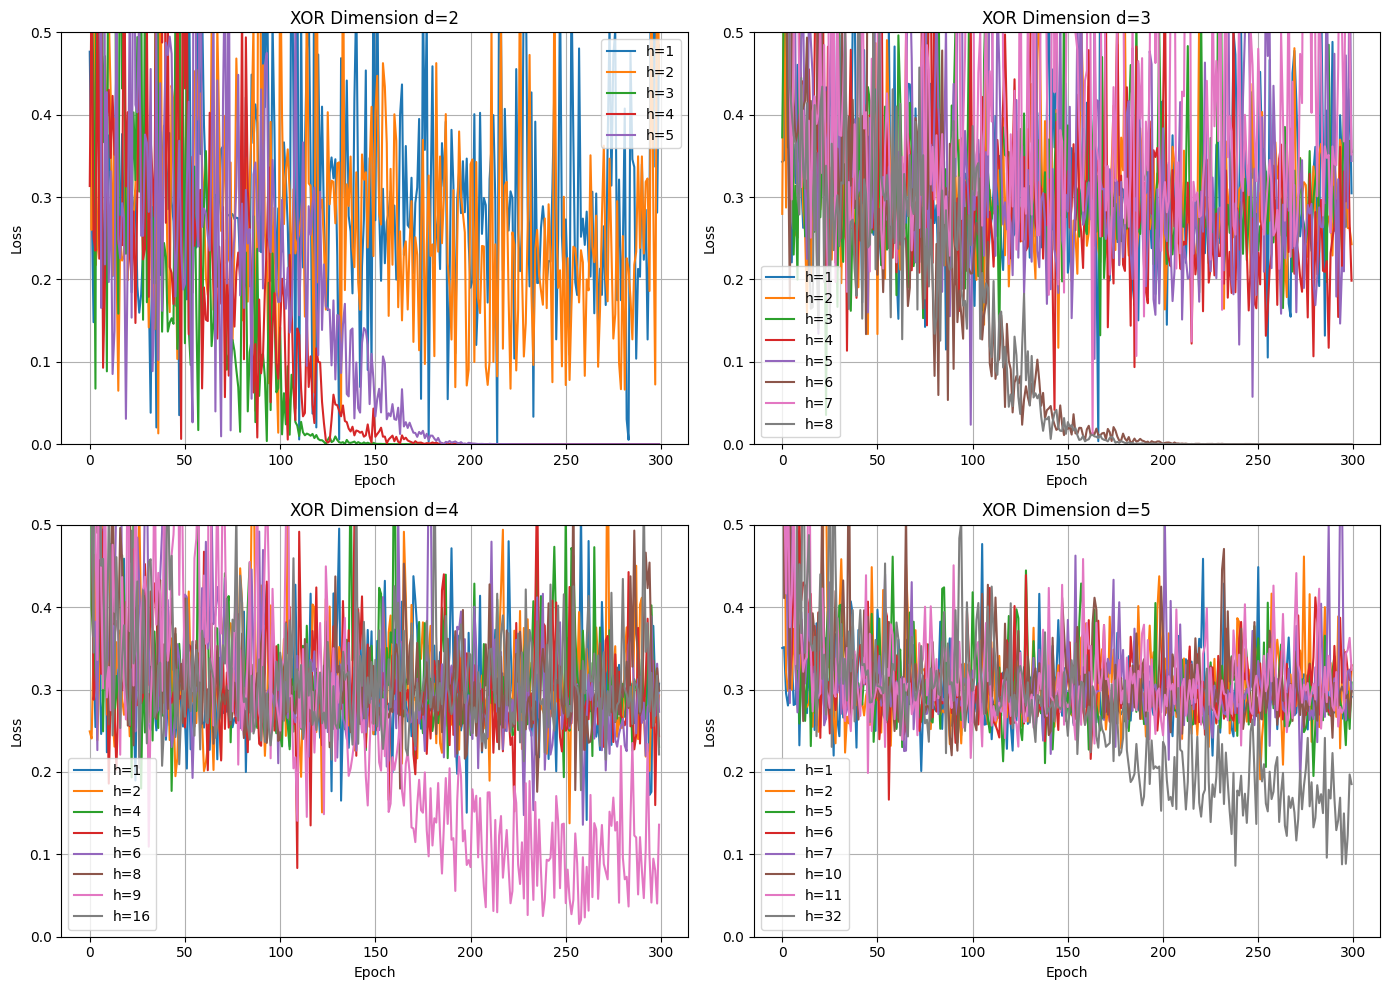

In [ ]:
import matplotlib.pyplot as plt

# Store results for plotting
results = {}

# Test dimensions
dimensions = [2, 3, 4, 5]

# Modified train function that returns loss history
def train_with_history(net, X, Y, epochs=300):
    loss_history = []
    steps = X.shape[0]
    for i in range(epochs):
        epoch_loss = 0
        for j in range(steps):
            data_point = np.random.randint(X.shape[0])
            x_var = torch.Tensor(X[data_point])
            y_var = torch.Tensor([Y[data_point]])
            optimizer.zero_grad()
            y_hat = net(x_var)
            loss = loss_func(y_hat, y_var)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / steps)
    return loss_history

# Run experiments
for d in dimensions:
    print(f"\n{'='*50}")
    print(f"Testing dimension d = {d}")
    print(f"{'='*50}")

    X, Y = XORData(d)
    print(f"Dataset size: {X.shape[0]} samples")

    # Hidden sizes to try
    hidden_sizes = [1, 2, d, d+1, d+2, 2*d, 2*d+1, min(2**d, 32)]
    hidden_sizes = sorted(list(set(hidden_sizes)))  # Remove duplicates, sort

    results[d] = {}

    for h_size in hidden_sizes:
        print(f"\n  Hidden size: {h_size}")

        # Create fresh model and optimizer
        model = FFNet(d, 1, h_size)
        optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9)

        # Train
        loss_history = train_with_history(model, X, Y, epochs=300)
        results[d][h_size] = loss_history

        print(f"    Final loss: {loss_history[-1]:.6f}")

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, d in enumerate(dimensions):
    ax = axes[idx]
    for h_size, losses in results[d].items():
        ax.plot(losses, label=f'h={h_size}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'XOR Dimension d={d}')
    ax.legend()
    ax.set_ylim([0, 0.5])  # Adjust as needed
    ax.grid(True)

plt.tight_layout()
plt.savefig('xor_experiments.png', dpi=150)
plt.show()


<font color="red">**Answer the following questions:** </font>

1. For which dimensions were you able to reach a model that converges (loss value is geting close to 0)?

<font color="red">Only d=2 and d=3 converged. For d=4 and d=5, no hidden layer size achieved convergence within 300 epochs.</font>

2. What is the number of hidden neurons in that network and how did you find it?

<font color="red">For d=2, hidden_size=3 is the minimum that converged (h=3,4,5 all achieved loss≈0, while h=1,2 failed). For d=3, hidden_size=6 is the minimum that worked (h=6 and h=8 achieved loss≈0, while h=7 failed despite being larger than h=6). For d=4 and d=5, no tested hidden size achieved convergence. We found these values by systematically testing hidden sizes from the set {1, 2, d, d+1, d+2, 2d, 2d+1, 2^d} and observing which achieved loss close to 0.</font>

3. What results did you expect and how does it differ from the results you achieved?

<font color="red"> We expected larger hidden layers to guarantee convergence, but results show high sensitivity to random initialization—the same architecture can succeed or fail depending on initial weights. The Universal Approximation Theorem guarantees a solution exists, but SGD may not find it.
Running the experiment multiple times showed that even h=2 for d=2 sometimes fails, This demonstrates that optimization success depends heavily on initialization, not just network capacity</font>



### Backpropagation

The following part will focus on the computaion of gradients with respect to the model parameters, aimed at understanding the functioning of `loss.backward()`.

Implement the function:`calc_gradients(net, x, loss)` with the following instructions:

- Input: instance of `FFNet` with a hidden layer of size 2, input of size 2 and output of size 1, input vector `x` and `loss` value.

- Output: One dimensional tensor with the gradients of the loss w.r.t each of the parameters, ordered as the corresponding parameters order `net.parameters()` returns (if we would flatten it's output).

1. Compute (by hand) the derivatives w.r.t the second linear layer parameters.
2. Use the chain rule to compute (by hand) the derivatives w.r.t the first linear layer parameters.
3. Implement the final form computations per parameter.
4. Order the gradients as described above.


In [ ]:
def calc_gradients(net, x, y_var, y_hat, loss):
    """
    Manually compute gradients for a 2-2-1 FFNet.

    Args:
        net: FFNet instance with layer1 and layer2
        x: input tensor of shape (2,)
        y_var: target value tensor of shape (1,)
        y_hat: predicted value tensor of shape (1,)
        loss: scalar loss value (MSE)

    Returns:
        Flattened tensor of all gradients in order:
        [dW1 (flattened), db1, dW2 (flattened), db2]
    """
    # Get weights from network
    W1 = net.layer1.W  # (2, 2)
    b1 = net.layer1.b  # (2,)
    W2 = net.layer2.W  # (2, 1)
    b2 = net.layer2.b  # (1,)

    # ===== Forward pass (recompute intermediate values) =====
    z1 = x @ W1 + b1           # Pre-activation of hidden layer (2,)
    h = torch.sigmoid(z1)       # Hidden layer output (2,)
    # z2 = h @ W2 + b2 = y_hat  # Output

    # ===== Backward pass =====

    # Gradient of MSE loss: L = (y_hat - y)^2
    # dL/dy_hat = 2 * (y_hat - y)
    dL_dy_hat = 2 * (y_hat - y_var)  # (1,)

    # ----- Layer 2 gradients -----
    # y_hat = h @ W2 + b2
    # dL/dW2 = h^T * dL/dy_hat
    dL_dW2 = h.unsqueeze(1) @ dL_dy_hat.unsqueeze(0)  # (2,1)
    # dL/db2 = dL/dy_hat
    dL_db2 = dL_dy_hat  # (1,)

    # Backprop to hidden layer
    # dL/dh = dL/dy_hat * W2^T
    dL_dh = dL_dy_hat @ W2.T  # (1,) @ (1,2) = (2,)
    dL_dh = dL_dh.squeeze()   # Ensure shape is (2,)

    # ----- Sigmoid backward -----
    # sigmoid'(z) = sigmoid(z) * (1 - sigmoid(z)) = h * (1 - h)
    sigmoid_grad = h * (1 - h)  # (2,)
    dL_dz1 = dL_dh * sigmoid_grad  # (2,) element-wise

    # ----- Layer 1 gradients -----
    # z1 = x @ W1 + b1
    # dL/dW1 = x^T * dL/dz1
    dL_dW1 = x.unsqueeze(1) @ dL_dz1.unsqueeze(0)  # (2,1) @ (1,2) = (2,2)
    # dL/db1 = dL/dz1
    dL_db1 = dL_dz1  # (2,)

    # ===== Concatenate all gradients in parameter order =====
    # Order: W1, b1, W2, b2 (matching net.parameters())
    grads = torch.cat([
        dL_dW1.view(-1),   # Flatten W1 gradient
        dL_db1.view(-1),   # Flatten b1 gradient
        dL_dW2.view(-1),   # Flatten W2 gradient
        dL_db2.view(-1)    # Flatten b2 gradient
    ])

    return grads

Run the following cell to check the correctness of your computation:

In [ ]:
def equal_gradients(net, x, y_var, y_hat, loss):
  grads = []
  for param in net.parameters():
    grads.append(param.grad.view(-1))
  grads = torch.cat(grads)
  return True if torch.sum(grads - calc_gradients(net, x, y_var, y_hat, loss)).round() == 0 else False # Added round because results were very close but not identical

def train_and_compare(net, X, Y, epochs=100):
  steps = X.shape[0]
  for i in range(epochs):
      for j in range(steps):
          data_point = np.random.randint(X.shape[0])
          x_var = torch.Tensor(X[data_point])
          y_var = torch.Tensor([Y[data_point]])
          optimizer.zero_grad()
          y_hat = net(x_var)
          loss = loss_func(y_hat, y_var)
          loss.backward()
          if not equal_gradients(net, x_var, y_var, y_hat, loss.item()):
            print("Wrong gradients computation!")
            return
          optimizer.step()
  print("Correct gradients computation!")

model = FFNet(2, 1, 2)
optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9)
X, Y = XORData(2)


train_and_compare(model, X, Y)

Correct gradients computation!
